# Predict Molecular Property using Graph Neural Network

## Install Dependencies

In [ ]:
!pip install seaborn torch torch_geometric rdkit wget tqdm

## Download Dataset

In [2]:
!python -m \
    wget https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv


Saved under delaney-processed.csv


## Import Packages

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.patches as patches
mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2

import tqdm

import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem


import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn.conv import GCNConv
from torch_geometric.nn.pool import global_mean_pool

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Load Dataset

In [5]:
DELANEY_FILE = "delaney-processed.csv"
TASK_COL = 'measured log solubility in mols per litre'
df = pd.read_csv(DELANEY_FILE)
print(f"Number of molecules in the dataset: {df.shape[0]}")

Number of molecules in the dataset: 1128


Create molecule from SMILES

In [6]:
df["mol"] = df["smiles"].apply(lambda x: Chem.MolFromSmiles(x))

df = df[df["mol"].notna()]

In [7]:
# we will keep the following columns and discard the rest
df = df[["Compound ID", TASK_COL, "smiles", "mol"]]
df

,Compound ID,measured log solubility in mols per litre,smiles,mol
0,Amigdalin,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x7b4a78f01b60>
1,Fenfuram,-3.300,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x7b4a78f01a80>
2,citral,-2.060,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x7b4a78f01af0>
3,Picene,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x7b4a78f01bd0>
4,Thiophene,-1.330,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x7b4a78f01c40>
...,...,...,...,...
1123,halothane,-1.710,FC(F)(F)C(Cl)Br,<rdkit.Chem.rdchem.Mol object at 0x7b4a78e6ca50>
1124,Oxamyl,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x7b4a78e6cac0>
1125,Thiometon,-3.091,CCSCCSP(=S)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x7b4a78e6cb30>
1126,2-Methylbutane,-3.180,CCC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7b4a78e6cba0>


## Convert "mol" in rdkit to molecualr graphs

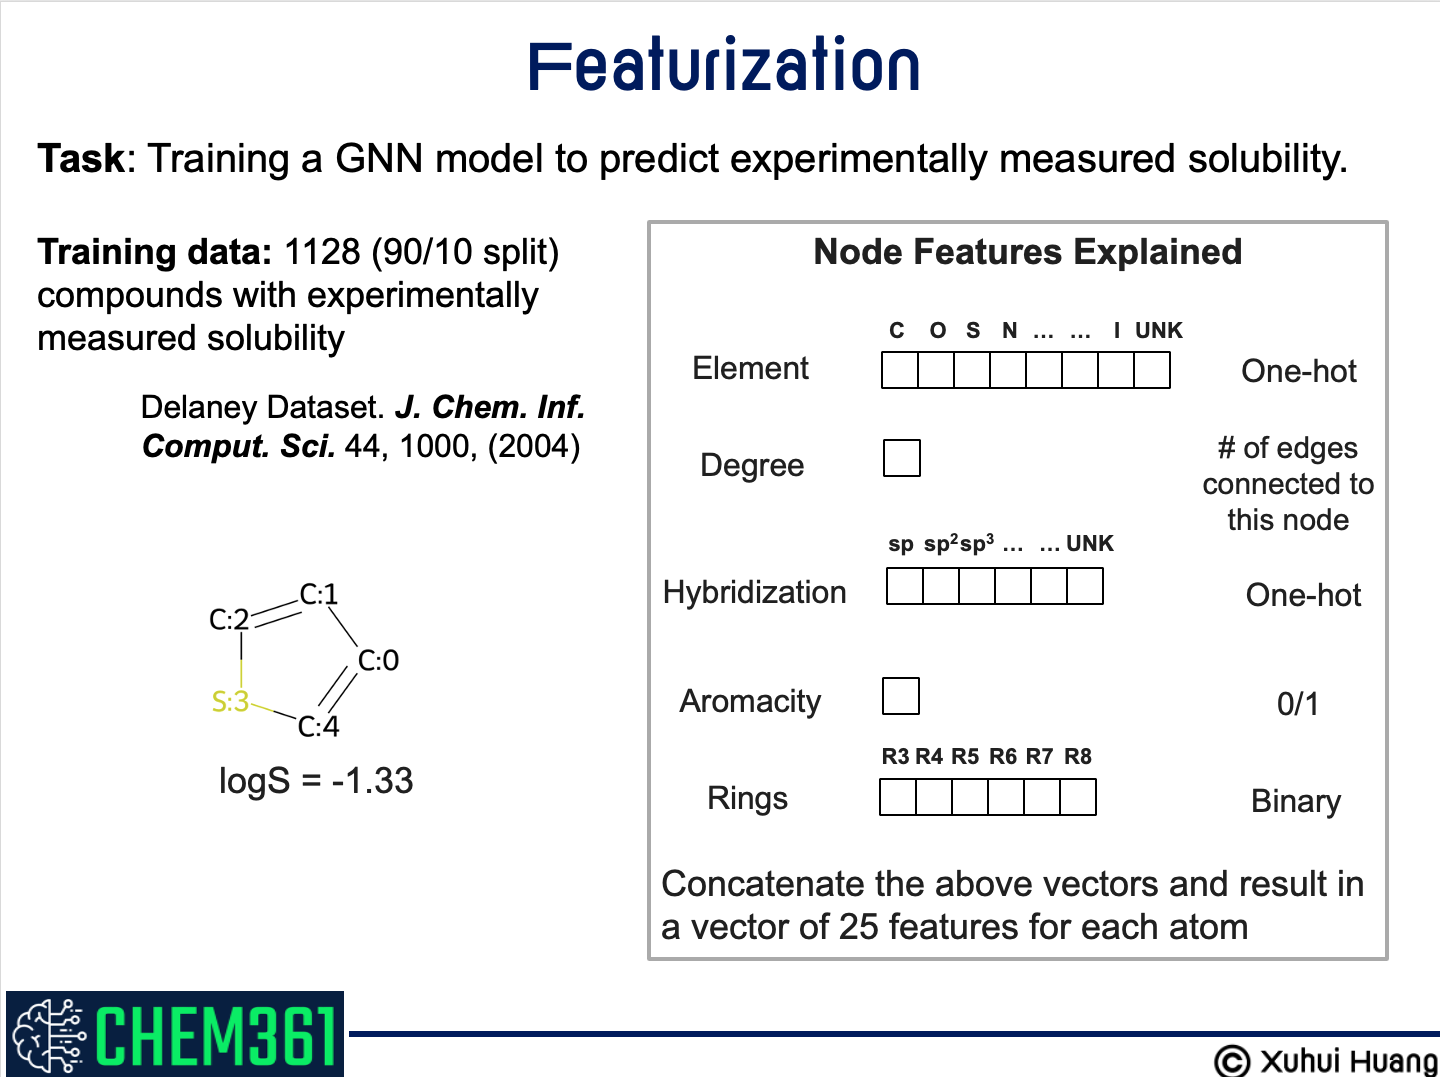

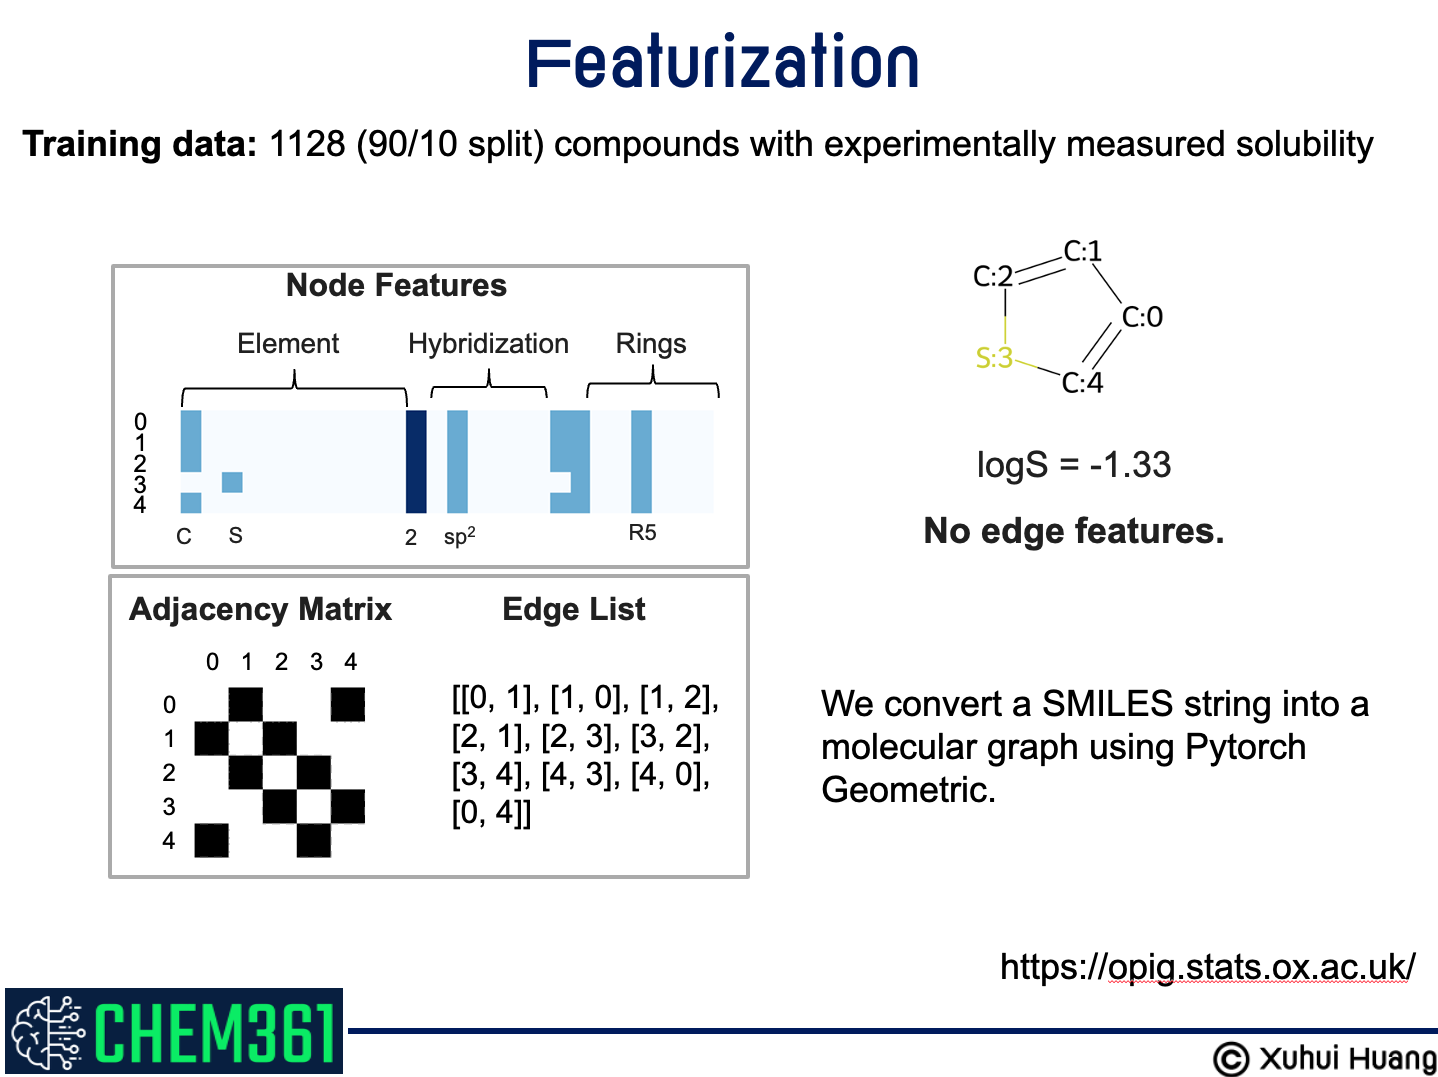

We follow this blog to convert "mol" to molecualr graphs.
https://www.blopig.com/blog/2022/02/how-to-turn-a-smiles-string-into-a-molecular-graph-for-pytorch-geometric/

There are two changes compared to the implementation in the original blog:
1. The molecules are not embedded to 3D structures.
2. The edge embeddings are not considered.

In [8]:
def mol2graph(mol):
    # calculate node features
    ATOMS = ['C', 'O', 'S', 'N', 'P', 'H', 'F', 'Cl', 'Br', 'I', 'UNK']
    ATOM2DCT = {ele: (np.eye(len(ATOMS))[idx]).tolist() for idx, ele in enumerate(ATOMS)}
    HYBRIDS = [Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
        'UNK']
    HYBRID2DCT = {ele: (np.eye(len(HYBRIDS))[idx]).tolist() for idx, ele in enumerate(HYBRIDS)}

    x = []
    ring = mol.GetRingInfo()
    for idx in range(mol.GetNumAtoms()):
        emd = []
        at = mol.GetAtomWithIdx(idx)
        ele = at.GetSymbol()
        ele = ele if ele in ATOMS else 'UNK'
        emd += ATOM2DCT[ele] # add atom type
        emd += [at.GetDegree()]
        hyb = at.GetHybridization()
        hyb = hyb if hyb in HYBRIDS else "UNK"
        emd += HYBRID2DCT[hyb] # add atom hybridization type
        emd += [at.GetIsAromatic()] # add atom aromacity
        emd += [ring.IsAtomInRingOfSize(idx, 3),
              ring.IsAtomInRingOfSize(idx, 4),
              ring.IsAtomInRingOfSize(idx, 5),
              ring.IsAtomInRingOfSize(idx, 6),
              ring.IsAtomInRingOfSize(idx, 7),
              ring.IsAtomInRingOfSize(idx, 8)] # add ring size
        x.append(emd)
    x = torch.Tensor(np.array(x)).float()

    # calculate edges
    bonds = []
    for bond in mol.GetBonds():
        idx1 = bond.GetBeginAtomIdx()
        idx2 = bond.GetEndAtomIdx()
        bonds.append([idx1, idx2])
        bonds.append([idx2, idx1])

    # create graph
    edge_index = torch.Tensor(np.array(bonds)).long()
    data = Data(x=x, edge_index=edge_index.t().contiguous())
    return data

## Visulize one of the compoudns in the dataset

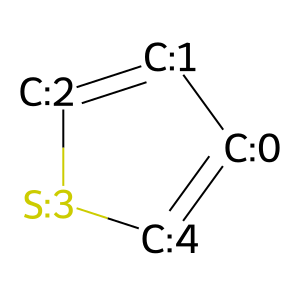

In [9]:
mol = df.iloc[4]["mol"]

from IPython.display import SVG
def draw_single_mol(mol, size=(300, 300), **highlights):
    # copy the molecule to avoid modifying the 3D coordinates
    mol = Chem.Mol(mol)
    drawer = Chem.Draw.rdMolDraw2D.MolDraw2DSVG(*size)
    if highlights is not None:
        Chem.Draw.rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, **highlights)
    else:
        drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return svg.replace('svg:','')

def mol_with_atom_index(mol):
    for atom in mol.GetAtoms():
        atom.SetProp("molAtomMapNumber", f"{atom.GetIdx()}")
    return mol

SVG(draw_single_mol(mol_with_atom_index(mol)))

## Visulize a moleuclar graph

In [10]:
g = mol2graph(mol)
g

Data(x=[5, 25], edge_index=[2, 10])

## Node embeddings

The above molecule contains 5 heavy atoms (non-hydrogen atoms). Each atom is embedded to a 25-dim vector. Therefore the node embeddings of the graph has the shape of $5\times 25$.

In [11]:
g.x

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 1., 0., 0., 0., 0.,
         1., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 1., 0., 0., 0., 0.,
         1., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 1., 0., 0., 0., 0.,
         1., 0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 1., 0., 0., 0., 0.,
         1., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 1., 0., 0., 0., 0.,
         1., 0., 0., 1., 0., 0., 0.]])

## Edge list

The molecule has 5 bonds, but each bonds will be counted twice as $i \to j$ and $j \to i$ in the directed graph, resulting in 10 edges.

In [12]:
g.edge_index.T

tensor([[0, 1],
        [1, 0],
        [1, 2],
        [2, 1],
        [2, 3],
        [3, 2],
        [3, 4],
        [4, 3],
        [4, 0],
        [0, 4]])

## Batch compoudns for training

In [13]:
class MolGraphDataset(Dataset):
    def __init__(self, df, mol_col="mol", target_col=TASK_COL, transform_fn=None):
        super().__init__()
        self.df = df
        self.mol_col = mol_col
        self.target_col = target_col
        self.transform_fn = transform_fn

    def len(self):
        return len(self.df)

    def get(self, idx):
        row = self.df.iloc[idx]
        mol = row[self.mol_col]

        try:
            G = self.transform_fn(mol)
            if self.target_col is not None:
                target = torch.tensor([row[self.target_col]], dtype=torch.float)
                G.y = target
        except:
            return None

        return G

## Split Dataset

In [14]:
from sklearn.model_selection import train_test_split

# training/validation dataset
data_size = df.shape[0]
test_ratio = 0.10
test_size = int(data_size*test_ratio)
train_indices, test_indices = train_test_split(range(data_size), test_size=test_size, shuffle=True)
print(f"Training size: {len(train_indices)}, test size: {len(test_indices)}")
train_df, test_df = df.iloc[train_indices], df.iloc[test_indices]

Training size: 1016, test size: 112


## Please note here: we are using `DataLoader` from `torch_geometric.loader`, not `torch.utils.data.DataLoader`. The dataloader from `torch_geometric` helps combine several graphs to one batch (a large graph).

In [15]:
# create dataloaders
batch_size = 32
train_data = MolGraphDataset(train_df, transform_fn=mol2graph)
train_loader = DataLoader(train_data, batch_size=batch_size,
                                           shuffle=True, drop_last=False)
test_data = MolGraphDataset(test_df, transform_fn=mol2graph)
test_loader = DataLoader(test_data, batch_size=batch_size,
                                          shuffle=False, drop_last=False)

## Vislulization of graph batching (batch 5 compounds in a single graph)

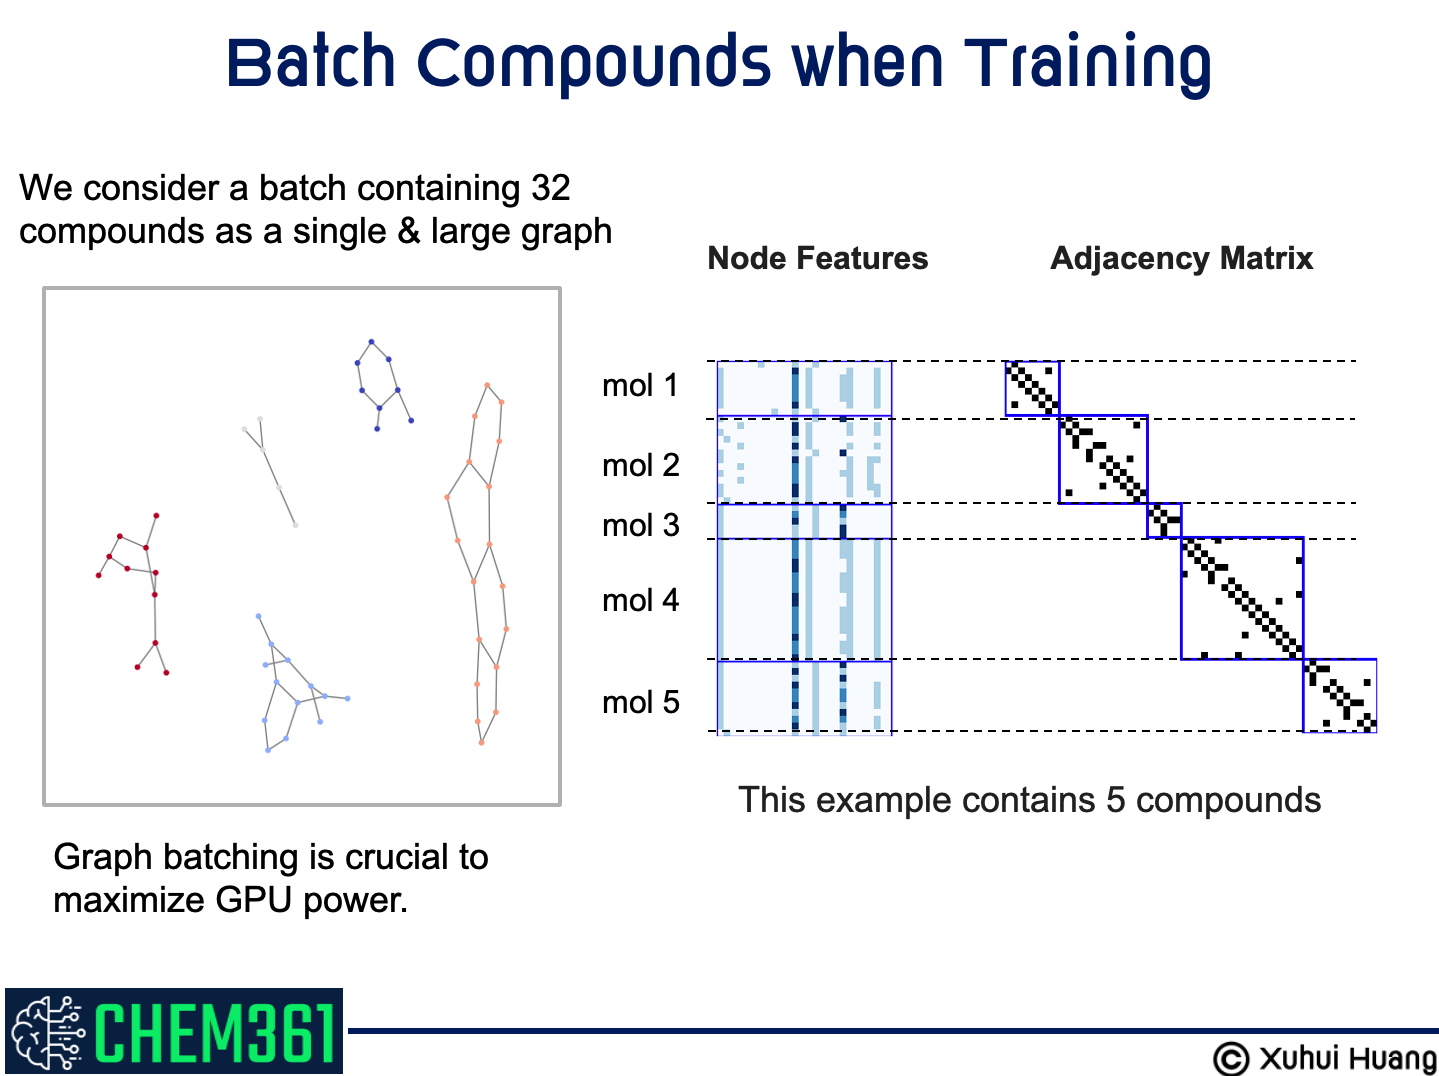

DataBatch(x=[63, 25], edge_index=[2, 128], y=[5], batch=[63], ptr=[6])


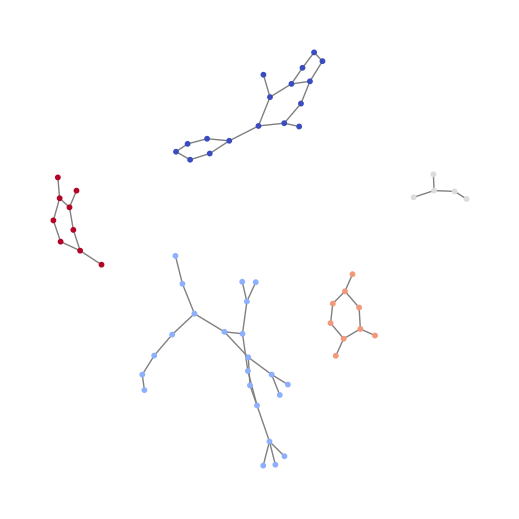

In [16]:
# combine 5 graphs to one batch
batch = next(iter(DataLoader(train_data, batch_size=5,
                        shuffle=True, drop_last=False)))
print(batch)


import networkx as nx
# build a graph from the edge list of the large graph
n = batch.x.shape[0]
batch_ids = np.array(batch.batch.tolist())

edges = np.array(batch.edge_index.T.tolist())
G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from([edges[i] for i in range(edges.shape[0])
                  if edges[i][0] < edges[i][1]])

node_colors = [batch_ids[i] for i in G.nodes]

plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G)
nx.draw(G, pos=pos, with_labels=False, node_color=node_colors, cmap="coolwarm",
        edge_color="gray", node_size=10)
plt.show()

## Visualize node features by batch ids

(np.float64(-0.5), np.float64(24.5), np.float64(62.5), np.float64(-0.5))

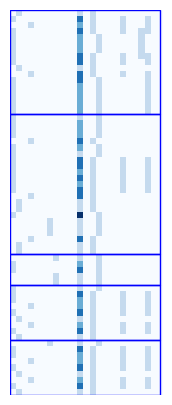

In [17]:
unique_batch_ids = np.unique(batch_ids)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.imshow(np.array(batch.x.tolist()), cmap="Blues", interpolation='none')

for batch_id in unique_batch_ids:
    indices = np.where(batch_ids == batch_id)[0]
    start, end = indices[0], indices[-1]
    rect = patches.Rectangle((-0.5, start-0.5), batch.x.shape[1]-0.5, end-start+1,
                                linewidth=1, edgecolor='blue', facecolor='none', linestyle='-')
    ax.add_patch(rect)

plt.axis("off")

## Visualize Adjacency matrix of the batched graph

[[0 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 0 1 0]]


(np.float64(-0.5), np.float64(62.5), np.float64(62.5), np.float64(-0.5))

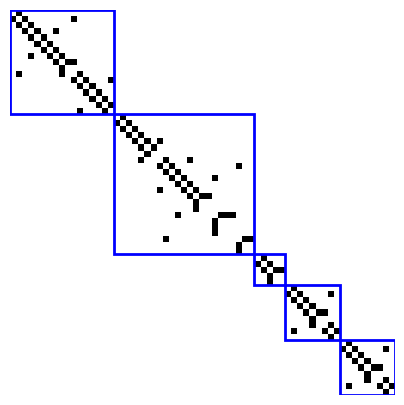

In [18]:
def edge_list_to_adjacency_matrix(edge_list, num_nodes):
    adj_matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    for u, v in edge_list:
        adj_matrix[u][v] = 1
    return adj_matrix

adj_matrix = edge_list_to_adjacency_matrix(edges, n)
print(adj_matrix)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plt.imshow(1-adj_matrix, cmap="gray")

# add diagonal blocks
unique_batch_ids = np.unique(batch_ids)
lw = 2
for batch_id in unique_batch_ids:
    indices = np.where(batch_ids == batch_id)[0]
    start, end = indices[0], indices[-1]
    rect = patches.Rectangle((start-0.5, start-0.5), end-start+1, end-start+1,
                                linewidth=lw, edgecolor='blue', facecolor='none', linestyle='-')
    ax.add_patch(rect)

plt.axis("off")

## GCN Model

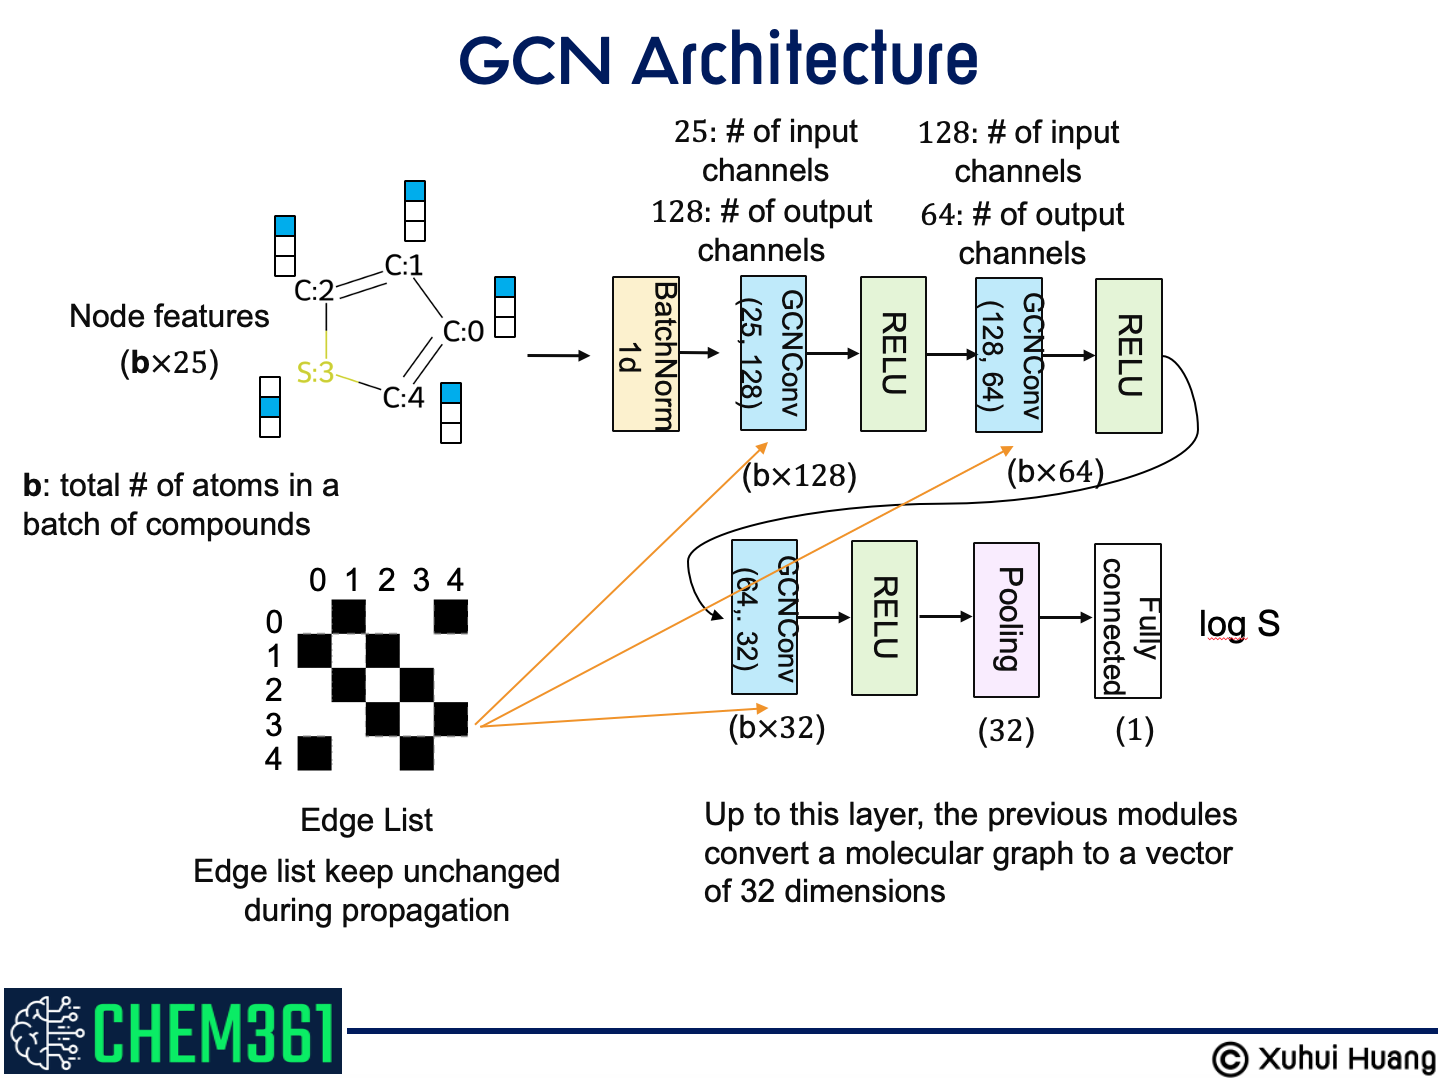

In [19]:
class GCNModel(nn.Module):
    def __init__(self, ndim, hidden_dims):
        super(GCNModel, self).__init__()
        total_dims = [ndim] + hidden_dims
        net = []
        self.bn = nn.BatchNorm1d(total_dims[0])

        ##set up the graph convolutional layer ndim=25 (25 node features, input channels for GCN)
        #hidden-dimes: output channel of the convolutional layer
        # 3 GCN layers, len(total_dims)=4
        for i in range(len(total_dims)-1):
            net.extend([
                GCNConv(total_dims[i], total_dims[i+1], add_self_loops=True),
                nn.ReLU(),
            ])
        self.net = nn.Sequential(*net)
        self.fc = nn.Linear(total_dims[-1], 1)


    def forward(self, data):
        batch = data.batch
        out = data.x

        out = self.bn(out)
        edge_index = data.edge_index.long()

        for idx in range(len(self.net)//2):
            out = self.net[2*idx](out, edge_index)
            out = self.net[2*idx+1](out)

         # pool each molecule to one vector
        out = global_mean_pool(out, batch)
        # fully connected layer
        out = self.fc(out)
        return out

In [20]:
def train_one_epcoh(model, criterion, optimizer, dataloader):
    losses = []
    model.train()
    for G in dataloader:
        if device == "cuda":
            G = G.to(device)
        y_true = G.y
        optimizer.zero_grad()
        y_pred = model(G)
        loss = criterion(y_pred, y_true.reshape(y_pred.shape))
        loss.backward()
        optimizer.step()
        losses.append(loss.cpu().detach().item())
    return losses


def val_one_epcoh(model, criterion, dataloader):
    losses = []
    model.eval()
    with torch.no_grad():
        for G in dataloader:
            if device == "cuda":
                G = G.to(device)
            y_true = G.y
            y_pred = model(G)
            loss = criterion(y_pred, y_true.reshape(y_pred.shape))
            losses.append(loss.cpu().detach().item())
    return losses

## Training

In [21]:
model = GCNModel(ndim=25, hidden_dims=[128, 64, 32]) # we stack 3 GCNs with dimensions: 128, 64 and 32
model.to(device)
model = model.float()

n_epochs = 200
lr = 5e-3 #learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
print("Number of trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.MSELoss() #Mean square error loss

train_loss = []
val_loss = []
for epoch in tqdm.tqdm(range(n_epochs)):
    losses = train_one_epcoh(model, criterion, optimizer, train_loader)
    train_loss.append(np.mean(losses))
    losses = val_one_epcoh(model, criterion, test_loader)
    val_loss.append(np.mean(losses))

Number of trainable parameters: 13747


100%|██████████| 200/200 [03:10<00:00,  1.05it/s]


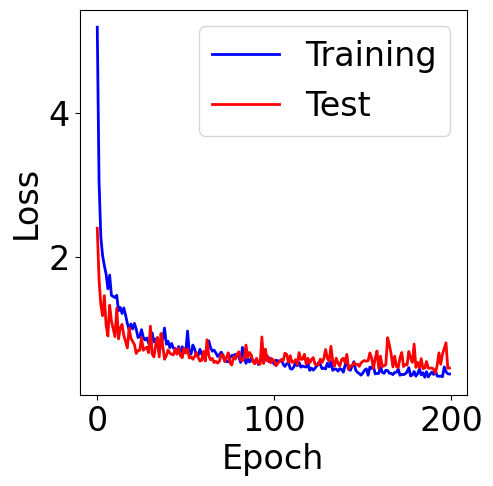

In [22]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(train_loss, c="blue", label="Training")
ax.plot(val_loss, c="red", label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

## Evaluation Metrics

In [23]:
truths = []
predictions = []
model.eval()
with torch.no_grad():
    for G in test_loader:
        if device == "cuda":
            G = G.to(device)
        y = G.y
        y_pred = model(G).reshape(-1)
        # predictions.extend(y_pred.cpu().detach().numpy().tolist())
        predictions.extend([y_pred[i].item() for i in range(len(y_pred))])

        y = y.reshape(y_pred.shape)
        # truths.extend(y.cpu().numpy().tolist())
        truths.extend([y[i].item() for i in range(len(y))])

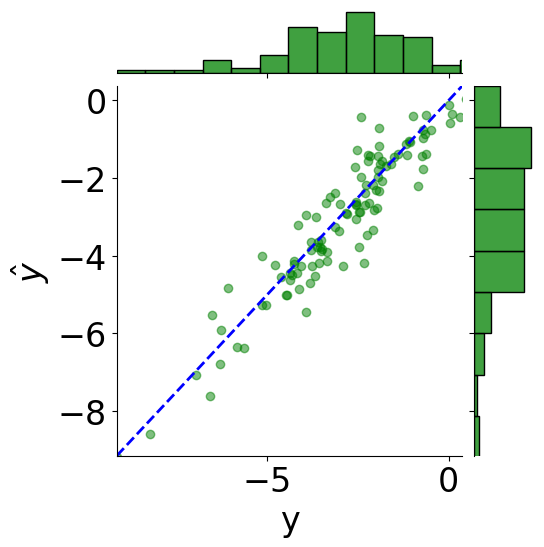

In [24]:
tmp_df = pd.DataFrame({"y": truths, r"$\hat{y}$": predictions})

# scatter plot
g = sns.JointGrid(x="y", y=r"$\hat{y}$", data=tmp_df)
g = g.plot_joint(plt.scatter, c="green", alpha=0.5)

# line: y_pred = y
y_line = np.linspace(np.min(truths), np.max(predictions), 200)
g.ax_joint.plot(y_line, y_line, color="blue", linestyle="--");

# histograms
g = g.plot_marginals(sns.histplot, data=df, color="green", kde=False)

g.ax_joint.set_xlim(np.min(y_line), np.max(y_line))
g.ax_joint.set_ylim(np.min(y_line), np.max(y_line))

plt.show()

In [25]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

print(f"MSE: {mean_squared_error(truths, predictions):.2f}")
print(f"Coefficient of determination: {r2_score(truths, predictions):.2f}")

MSE: 0.43
Coefficient of determination: 0.88
